---
title: "Workshop for day 2"
author: "Inspired by Rasmus F Brøndum"
date: "23/05/2025"
format:
  html:
    toc: true
    toc-float: true
---

This document provides the basis for loading the data and training some dynamic classification models using Python libraries like `scikit-learn`, `xgboost`, and `optuna`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, precision_score, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
import multiprocessing

np.random.seed(2025)
cores = multiprocessing.cpu_count()

Load and read the data.

In [2]:
df = pd.read_csv("Data_ready_for_workshop2.csv")

df

,id,date,systolic,diastolic,erythrocytes,hemoglobin,wbc,platelets,glucose,potassium,...,diff_chol,diff_hdl,diff_ldl,diff_cvscore,diff_anxiety,diff_sleep,diff_alcohol,diff_fruit,diff_vegetable,mevent_nyear
0,2,2005-06-10 00:00:00+00:00,0.400000,0.39,0.469412,0.280624,0.034524,0.198358,0.114286,0.393617,...,0.534341,0.206665,0.467559,0.278107,0.571429,0.500,0.5,0.500,0.500,0
1,2,2006-09-12 00:00:00+00:00,0.282353,0.35,0.496471,0.296214,0.027381,0.165527,0.120408,0.425532,...,0.510688,0.259157,0.449695,0.290603,0.571429,0.500,0.5,0.500,0.500,0
2,2,2007-10-15 00:00:00+00:00,0.529412,0.35,0.508235,0.305122,0.036905,0.261286,0.124490,0.457447,...,0.532863,0.263368,0.514877,0.363766,0.571429,0.250,0.5,0.625,0.500,0
3,2,2008-09-22 00:00:00+00:00,0.529412,0.60,0.475294,0.271715,0.030952,0.246238,0.110204,0.404255,...,0.446692,0.228954,0.387423,0.357349,0.571429,0.500,0.5,0.500,0.500,0
4,2,2009-09-21 00:00:00+00:00,0.411765,0.45,0.447059,0.253898,0.035119,0.172367,0.120408,0.404255,...,0.366175,0.244113,0.294675,0.324689,0.428571,0.625,0.5,0.500,0.625,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3904,1592,2007-06-09 00:00:00+00:00,0.364706,0.39,0.512941,0.314031,0.047024,0.363885,0.142857,0.000000,...,0.469661,0.258962,0.411395,0.345214,0.714286,0.625,0.5,0.500,0.375,0
3905,1593,2005-11-07 00:00:00+00:00,0.411765,0.55,0.556471,0.342984,0.051190,0.403557,0.226531,0.489362,...,0.585743,0.294292,0.559354,0.345855,0.571429,0.500,0.5,0.500,0.500,0
3906,1594,2005-10-03 00:00:00+00:00,0.470588,0.55,0.496471,0.298441,0.030952,0.184679,0.122449,0.500000,...,0.477715,0.263602,0.391281,0.369914,0.571429,0.500,0.5,0.500,0.500,0
3907,1595,2005-06-02 00:00:00+00:00,0.435294,0.47,0.556471,0.349666,0.038095,0.302326,0.126531,0.436170,...,0.558385,0.302181,0.549595,0.428949,0.571429,0.500,0.5,0.500,0.500,0


In [3]:
df_cal = df[df['split'] == 'calibration'].copy()
df = df[df['split'] != 'calibration'].copy()

df['split'] = pd.Categorical(df['split'], categories=['train', 'validation', 'test'], ordered=True)

df.sort_values('split', inplace=True)

split_counts = df['split'].value_counts()

# Prepare data
def prepare_data(data):
    X = data.drop(columns=['id', 'date', 'split', 'mevent_nyear'])
    y = LabelEncoder().fit_transform(data['mevent_nyear'])  # ensure 1 is positive class
    return X, y

X, y = prepare_data(df)
X_cal, y_cal = prepare_data(df_cal)
X.reset_index(drop = True)
X_cal.reset_index(drop = True)

,systolic,diastolic,erythrocytes,hemoglobin,wbc,platelets,glucose,potassium,creatine,chol,...,diff_creatine,diff_chol,diff_hdl,diff_ldl,diff_cvscore,diff_anxiety,diff_sleep,diff_alcohol,diff_fruit,diff_vegetable
0,0.364706,0.45,0.614118,0.365256,0.045833,0.229822,0.161224,0.425532,0.130233,0.408844,...,0.325284,0.560028,0.226527,0.531851,0.323160,0.571429,0.500000,0.500000,0.50000,0.500000
1,0.376471,0.37,0.590588,0.336303,0.047619,0.243502,0.132653,0.436170,0.146512,0.289116,...,0.368350,0.413693,0.279072,0.289232,0.324642,0.787257,0.480683,0.429877,0.54519,0.542581
2,0.341176,0.35,0.591765,0.351893,0.059524,0.217510,0.165306,0.425532,0.127907,0.265986,...,0.353224,0.410891,0.333282,0.331374,0.324772,0.428571,0.625000,0.500000,0.50000,0.500000
3,0.347059,0.35,0.576471,0.334076,0.042857,0.254446,0.146939,0.457447,0.137209,0.278912,...,0.371189,0.443391,0.277456,0.345571,0.341408,0.571429,0.500000,0.500000,0.50000,0.500000
4,0.352941,0.43,0.569412,0.336303,0.039286,0.202462,0.163265,0.382979,0.139535,0.331973,...,0.377793,0.512104,0.333370,0.425080,0.366146,0.714286,0.625000,0.500000,0.50000,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257,0.411765,0.55,0.592941,0.334076,0.042262,0.354309,0.093878,0.489362,0.216279,0.428571,...,0.407739,0.548612,0.197300,0.590495,0.339157,0.787257,0.605683,0.429877,0.54519,0.542581
258,0.470588,0.45,0.631765,0.347439,0.041071,0.383037,0.097959,0.500000,0.267442,0.455782,...,0.462897,0.570406,0.259681,0.594369,0.358234,0.571429,0.500000,0.500000,0.50000,0.500000
259,0.352941,0.45,0.591765,0.331849,0.037500,0.378933,0.097959,0.425532,0.183721,0.476190,...,0.347277,0.560287,0.241438,0.571607,0.344564,0.428571,0.500000,0.500000,0.50000,0.500000
260,0.352941,0.45,0.627059,0.354120,0.039881,0.425445,0.100000,0.404255,0.190698,0.299320,...,0.363555,0.373417,0.244290,0.233747,0.330918,0.571429,0.500000,0.500000,0.50000,0.500000


Data splitting

In [4]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=split_counts['test'], shuffle = False)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=split_counts['validation'], shuffle = False)

Basic Logistic Regression

In [5]:
blr_model = LogisticRegression(max_iter=1000)
blr_model.fit(X_train, y_train)
y_test_pred = blr_model.predict(X_test)
y_test_prob = blr_model.predict_proba(X_test)[:, 1]

print("Accuracy:", (y_test_pred == y_test).mean())
print("ROC AUC:", roc_auc_score(y_test, y_test_prob))

Accuracy: 0.9788732394366197
ROC AUC: 0.7175592859046096


ROC Curve

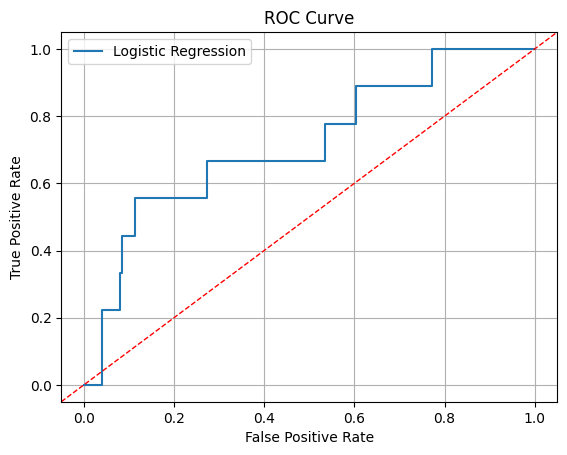

<Figure size 640x480 with 0 Axes>

In [6]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
plt.plot(fpr, tpr, label='Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.axline((0, 0), (1, 1), linewidth=1, linestyle = '--', color='r')
plt.show()
plt.clf()

Elastic Net Logistic Regression (Grid Search)

In [7]:
from sklearn.model_selection import GridSearchCV, PredefinedSplit

param_grid = {
    'C': 1 / np.logspace(-4, 0, 101),  # Inverse of regularization
    'l1_ratio': np.linspace(0, 1, 11)
}

# Using `saga` solver for elastic net logistic regression
lr_model = LogisticRegression(penalty='elasticnet', solver='saga', max_iter=5000)

test_fold = np.array([-1]*len(X_train) + [0]*len(X_val))

split = PredefinedSplit(test_fold)

lr_grid = GridSearchCV(
    lr_model,
    param_grid = {
        'C': 1 / np.logspace(-4, 0, 5),
        'l1_ratio': np.linspace(0, 1, 5)
    },
    scoring = 'roc_auc', cv = split, verbose = 2, n_jobs = cores
)

lr_grid.fit(X_train_val, y_train_val)
print("Best parameters:", lr_grid.best_params_)

Fitting 1 folds for each of 25 candidates, totalling 25 fits
Best parameters: {'C': 1.0, 'l1_ratio': 0.75}


ROC Curve

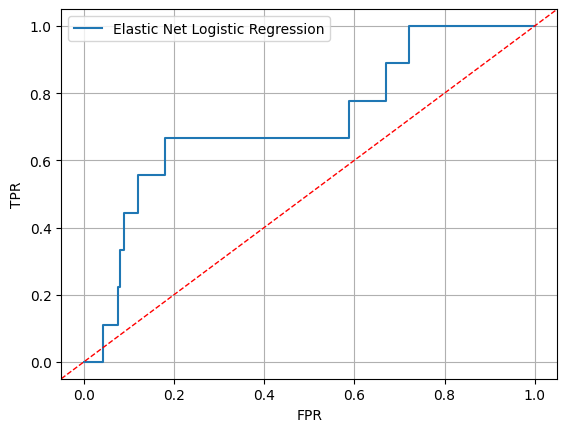

<Figure size 640x480 with 0 Axes>

In [8]:
lr_best = lr_grid.best_estimator_
y_test_prob = lr_best.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
plt.plot(fpr, tpr, label='Elastic Net Logistic Regression')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.axline((0, 0), (1, 1), linewidth=1, linestyle = '--', color='r')
plt.grid()
plt.show()
plt.clf()

Random Forest

In [9]:
from sklearn.model_selection import RandomizedSearchCV

rf_model = RandomForestClassifier(n_estimators=100, n_jobs=cores)

rf_grid = {
    'max_features': ['sqrt', 'log2', None],
    'min_samples_leaf': [1, 2, 4, 6, 8]
}

rf_search = RandomizedSearchCV(
    rf_model, rf_grid, n_iter=15, cv=split, scoring='roc_auc', n_jobs=cores
)
rf_search.fit(X_train_val, y_train_val)
print("Best RF parameters:", rf_search.best_params_)

Best RF parameters: {'min_samples_leaf': 4, 'max_features': 'sqrt'}


ROC

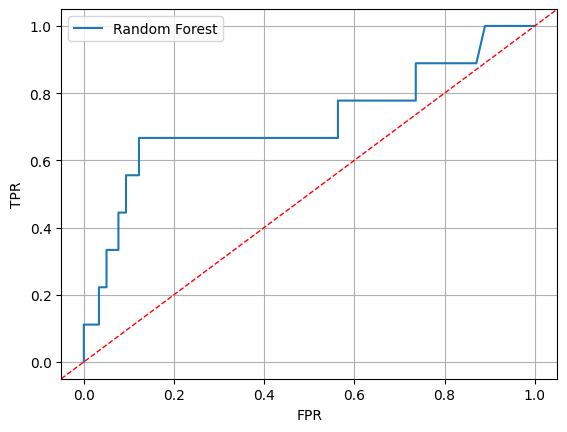

<Figure size 640x480 with 0 Axes>

In [10]:
rf_best = rf_search.best_estimator_
y_test_prob = rf_best.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
plt.plot(fpr, tpr, label='Random Forest')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.axline((0, 0), (1, 1), linewidth=1, linestyle = '--', color='r')
plt.grid()
plt.show()
plt.clf()

Gradient Boosted Trees (XGBoost)

In [11]:
gb_model = XGBClassifier(n_estimators=250, n_jobs=cores, eval_metric='logloss')

gb_grid = {
    'min_child_weight': [1, 5, 10],
    'gamma': [0, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1]
}

gb_search = RandomizedSearchCV(
    gb_model, gb_grid, n_iter=25, scoring='roc_auc', n_jobs=cores, cv=split
)
gb_search.fit(X_train_val, y_train_val)
print("Best GB parameters:", gb_search.best_params_)

Best GB parameters: {'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0}


ROC

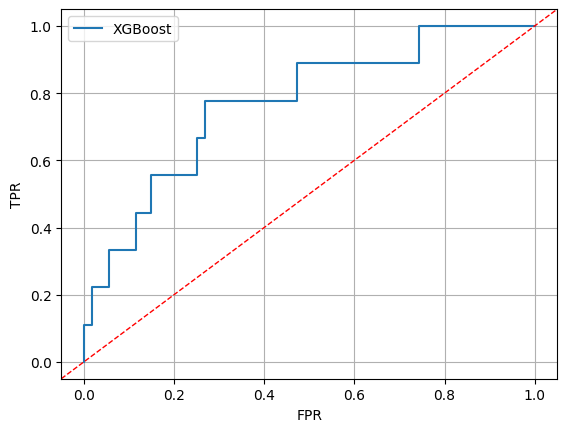

<Figure size 640x480 with 0 Axes>

In [12]:
xgb_best = gb_search.best_estimator_
y_test_prob = xgb_best.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
plt.plot(fpr, tpr, label='XGBoost')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.axline((0, 0), (1, 1), linewidth=1, linestyle = '--', color='r')
plt.grid()
plt.show()
plt.clf()

Multi-layer Perceptron (MLP)

In [13]:
mlp_grid = {
    'hidden_layer_sizes': [(10,), (30,), (50,)],
    'alpha': [0.00001, 0.0001, 0.001, 0.01, 0.1],
    'learning_rate_init': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
}

mlp_model = MLPClassifier(max_iter=1000, activation='logistic')

mlp_search = GridSearchCV(mlp_model, mlp_grid, scoring='roc_auc', cv=split, n_jobs=cores)
mlp_search.fit(X_train_val, y_train_val)
print("Best MLP parameters:", mlp_search.best_params_)

Best MLP parameters: {'alpha': 1e-05, 'hidden_layer_sizes': (30,), 'learning_rate_init': 0.01}


ROC

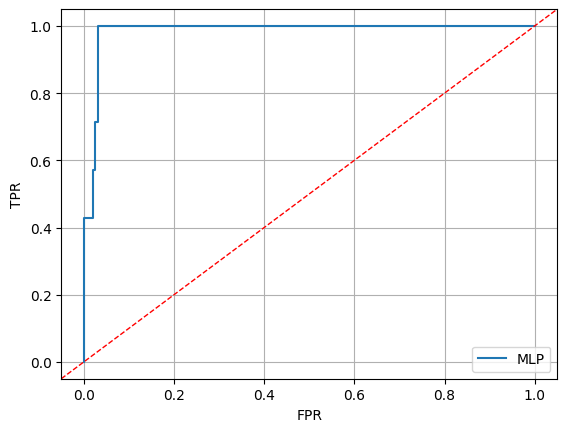

<Figure size 640x480 with 0 Axes>

In [14]:
mlp_best = mlp_search.best_estimator_
y_val_prob = mlp_best.predict_proba(X_val)[:, 1]
fpr, tpr, _ = roc_curve(y_val, y_val_prob)
plt.plot(fpr, tpr, label='MLP')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.axline((0, 0), (1, 1), linewidth=1, linestyle = '--', color='r')
plt.grid()
plt.show()
plt.clf()

Final Evaluation on Test Set

In [15]:
models = {
    'Logistic Regression': blr_model,
    'Elastic Net': lr_best,
    'Random Forest': rf_best,
    'XGBoost': xgb_best,
    'MLP': mlp_best
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(f"{name}")
    print("Precision:", precision_score(y_test, y_pred, zero_division = 0))
    print("ROC AUC:", roc_auc_score(y_test, y_prob))
    print("PR AUC:", average_precision_score(y_test, y_prob))
    print()

Logistic Regression
Precision: 0.0
ROC AUC: 0.7175592859046096
PR AUC: 0.06458492680064276

Elastic Net
Precision: 0.0
ROC AUC: 0.7148947508659739
PR AUC: 0.06022413139862352

Random Forest
Precision: 0.0
ROC AUC: 0.7159605648814281
PR AUC: 0.1842241431555626

XGBoost
Precision: 0.0
ROC AUC: 0.7695177191580069
PR AUC: 0.18300552198147288

MLP
Precision: 0.2
ROC AUC: 0.6802557953637091
PR AUC: 0.0962988996113052



(utestet kode herunder)

Feature Importance (when applicable)

**DEVNOTE: The following code needs NumPy 1.23.5 in the 'shap_values' function. The implementaion relies on a earlier version of numpy as the int statement changes in newer versions. See: https://stackoverflow.com/questions/74946845/attributeerror-module-numpy-has-no-attribute-int** 

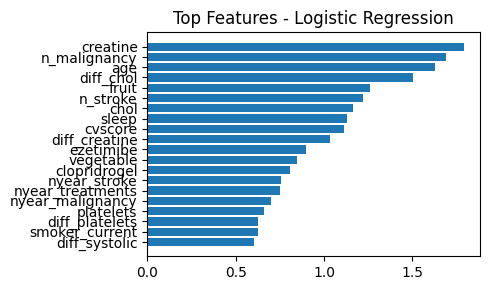

<Figure size 640x480 with 0 Axes>

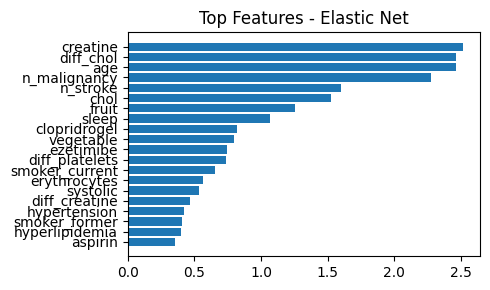

<Figure size 640x480 with 0 Axes>

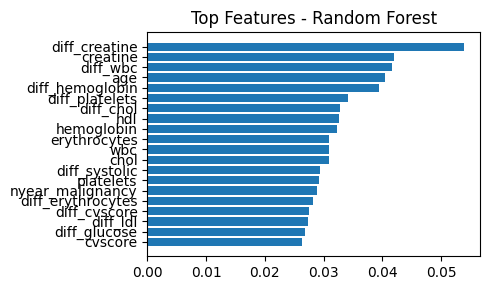

<Figure size 640x480 with 0 Axes>

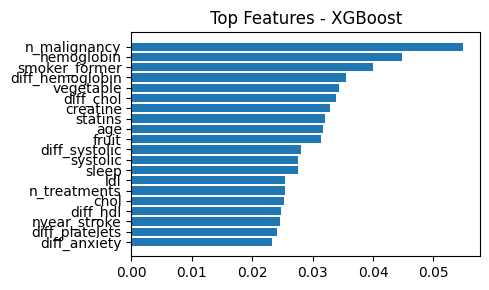

  0%|          | 0/10 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

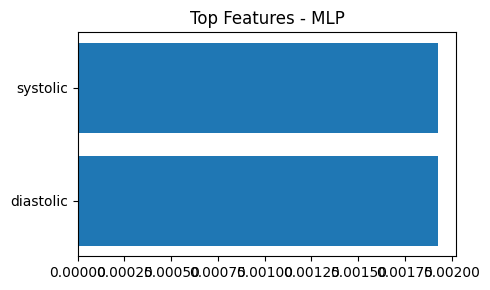

<Figure size 640x480 with 0 Axes>

In [17]:
from sklearn.inspection import permutation_importance
from itertools import chain
import shap
from sklearn.datasets import load_iris

for name, model in models.items():
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif name in {'Elastic Net', 'Logistic Regression'}:
        importances = np.array(list(chain.from_iterable([abs(number) for number in model.coef_])))
    else:
        # Use KernelExplainer (model-agnostic)
        explainer = shap.KernelExplainer(model.predict_proba, X_train[:50], rng = 42)
        shap_values = explainer.shap_values(X_test[:10], rng = 42)  # smaller subset for speed
        shap_array = np.array(shap_values[1])
        importances = np.abs(shap_array).mean(axis=0)

    top_idx = np.argsort(importances)[::-1][:20]
    plt.figure(figsize=(5,3))
    plt.barh(np.array(X.columns)[top_idx], importances[top_idx])
    plt.title(f"Top Features - {name}")
    plt.tight_layout()
    plt.gca().invert_yaxis()
    plt.show()
    plt.clf()

Calibration model.

C:\Users\jakob\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


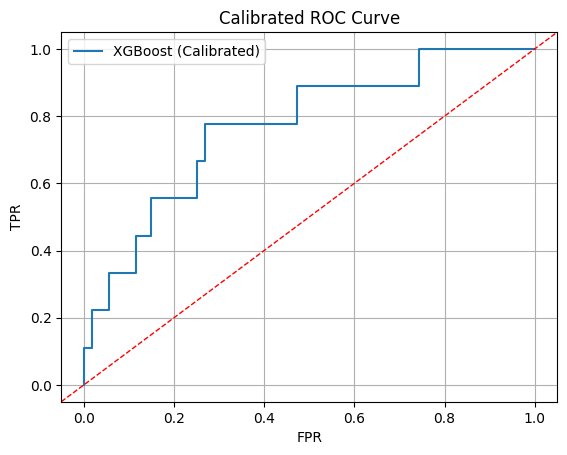

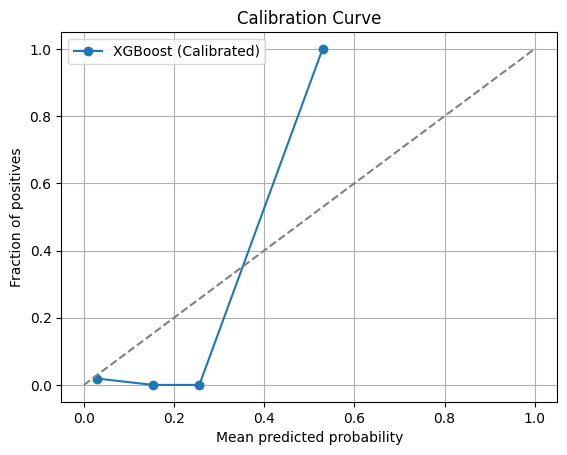

<Figure size 640x480 with 0 Axes>

In [19]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Fit calibrated model using the separate calibration set
xgb_calibrated = CalibratedClassifierCV(xgb_best, method='sigmoid', cv='prefit')
xgb_calibrated.fit(X_cal, y_cal)

# Evaluate calibrated model on the test set
y_test_prob_calibrated = xgb_calibrated.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_test_prob_calibrated)

plt.plot(fpr, tpr, label='XGBoost (Calibrated)')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.axline((0, 0), (1, 1), linewidth=1, linestyle='--', color='r')
plt.grid()
plt.title("Calibrated ROC Curve")
plt.show()
plt.clf()

# Calibration curve (Reliability diagram)
prob_true, prob_pred = calibration_curve(y_test, y_test_prob_calibrated, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o', label='XGBoost (Calibrated)')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve')
plt.legend()
plt.grid()
plt.show()
plt.clf()

Save model for workshop 3.

In [20]:
import joblib

# Save model
joblib.dump(blr_model, "trained_model.joblib")

['trained_model.joblib']